In [ ]:
#import common library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Data_Tingkat_Kemiskinan.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Kabupaten_Kota                  514 non-null    object 
 1   Tingkat_Penduduk_Miskin         514 non-null    float64
 2   Rata-rata Lama Sekolah          514 non-null    float64
 3   Indeks Pembangunan Gender       514 non-null    float64
 4   Usia Harapan Hidup              514 non-null    float64
 5   PengeluaranPerKapita            514 non-null    int64  
 6   Harapan Lama Sekolah            514 non-null    float64
 7   Produk Domestik Regional Bruto  514 non-null    float64
 8   Indeks Kemahalan Konstruksi     514 non-null    float64
 9   PengeluaranPerkapita_Rokok      514 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 40.3+ KB


In [ ]:
df.head()

,Kabupaten_Kota,Tingkat_Penduduk_Miskin,Rata-rata Lama Sekolah,Indeks Pembangunan Gender,Usia Harapan Hidup,PengeluaranPerKapita,Harapan Lama Sekolah,Produk Domestik Regional Bruto,Indeks Kemahalan Konstruksi,PengeluaranPerkapita_Rokok
0,Simeulue,17.69,9.89,79.78,65.73,8106,14.53,3150.76,108.80,22876
1,Aceh Singkil,19.06,8.72,85.51,67.89,9862,14.36,3441.08,94.32,24703
2,Aceh Selatan,12.02,8.92,92.24,64.97,9190,14.71,7466.23,98.65,22777
3,Aceh Tenggara,11.99,10.10,93.28,68.78,8876,14.47,6737.89,93.43,24582
4,Aceh Timur,13.26,8.48,87.26,69.18,9889,13.08,14935.34,95.47,28377


In [ ]:
from sklearn.model_selection import train_test_split

feature = df.drop(columns=['Tingkat_Penduduk_Miskin'])
target = df['Tingkat_Penduduk_Miskin']

feature_train, feature_test, target_train, target_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [ ]:
# calculate vif score for each column in feature_admit_train
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

# Drop the 'Kabupaten_Kota' column as VIF is for numerical features
X = add_constant(feature_train.drop(columns=['Kabupaten_Kota']))

vif_df = (pd.DataFrame(
            [vif(X.values, i) for i in range(len(X.columns))]
            ,index=X.columns)
            .reset_index())

vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,Rata-rata Lama Sekolah,3.256098
2,Indeks Pembangunan Gender,1.481402
3,Usia Harapan Hidup,1.620914
4,PengeluaranPerKapita,2.812529
5,Harapan Lama Sekolah,2.953565
6,Produk Domestik Regional Bruto,1.452568
7,Indeks Kemahalan Konstruksi,1.425318
8,PengeluaranPerkapita_Rokok,1.117878


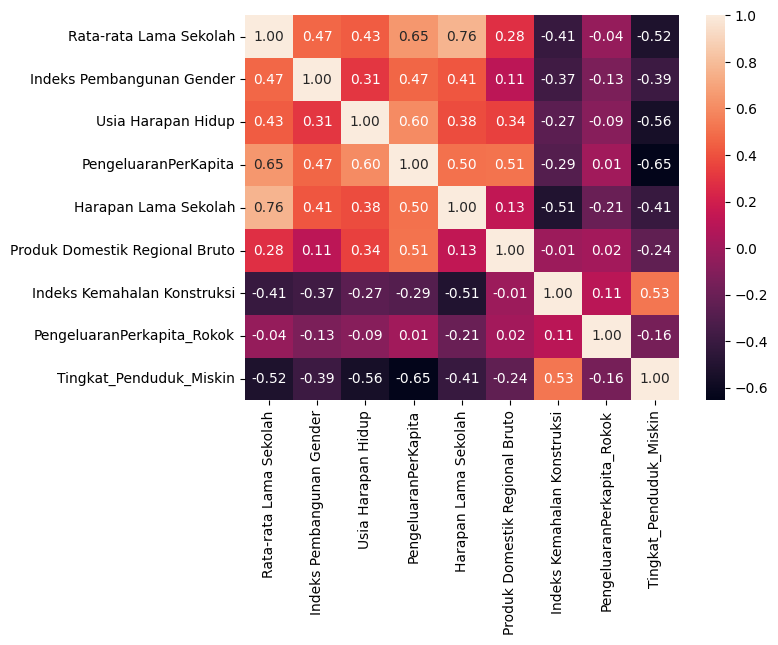

In [ ]:
# heatmap correlation
# Drop 'Kabupaten_Kota' as it is non-numeric and not relevant for correlation with other numerical features
admit_train = pd.concat([feature_train.drop(columns=['Kabupaten_Kota']), target_train], axis=1)
corr = admit_train.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Kabupaten_Kota                  514 non-null    object 
 1   Tingkat_Penduduk_Miskin         514 non-null    float64
 2   Rata-rata Lama Sekolah          514 non-null    float64
 3   Indeks Pembangunan Gender       514 non-null    float64
 4   Usia Harapan Hidup              514 non-null    float64
 5   PengeluaranPerKapita            514 non-null    int64  
 6   Harapan Lama Sekolah            514 non-null    float64
 7   Produk Domestik Regional Bruto  514 non-null    float64
 8   Indeks Kemahalan Konstruksi     514 non-null    float64
 9   PengeluaranPerkapita_Rokok      514 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 40.3+ KB


In [ ]:
feature_train = feature_train.drop(columns=['Harapan Lama Sekolah'])
feature_test = feature_test.drop(columns=['Harapan Lama Sekolah'])

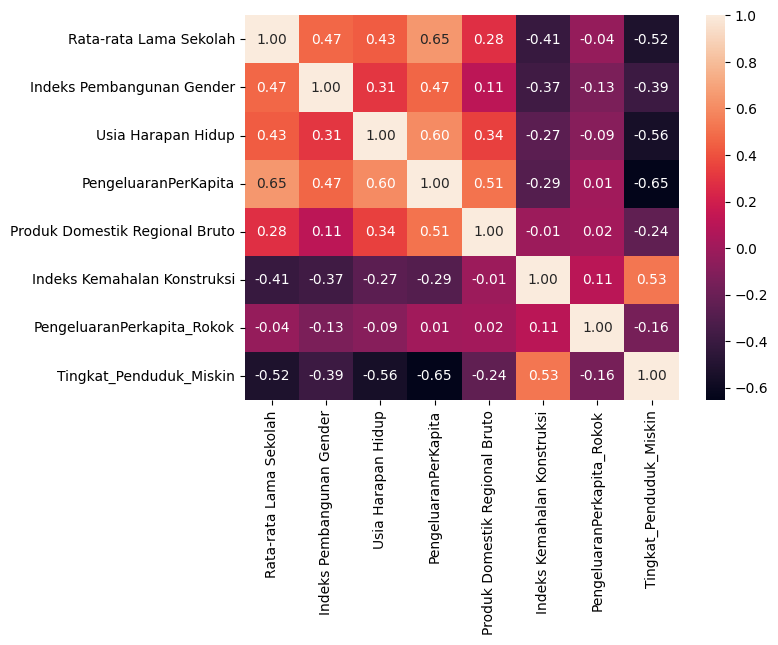

In [ ]:
# heatmap correlation
admit_train = pd.concat([feature_train.drop(columns=['Kabupaten_Kota']), target_train], axis=1)
corr = admit_train.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

In [ ]:
# calculate vif score for each column in feature_admit_train
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

# Drop the 'Kabupaten_Kota' column as VIF is for numerical features
X = add_constant(feature_train.drop(columns=['Kabupaten_Kota']))

vif_df = (pd.DataFrame(
            [vif(X.values, i) for i in range(len(X.columns))]
            ,index=X.columns)
            .reset_index())

vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,Rata-rata Lama Sekolah,1.970093
2,Indeks Pembangunan Gender,1.480311
3,Usia Harapan Hidup,1.617318
4,PengeluaranPerKapita,2.804190
5,Produk Domestik Regional Bruto,1.428284
6,Indeks Kemahalan Konstruksi,1.302598
7,PengeluaranPerkapita_Rokok,1.042474


ini yang baru


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
X_train = feature_train.drop(columns=['Kabupaten_Kota']).to_numpy()

In [ ]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_train)

    score = silhouette_score(X_train, labels)

    print(f"k={k}, score={score}")

k=2, score=0.8926613482180131
k=3, score=0.820893135254825
k=4, score=0.7612083318599524
k=5, score=0.5571443082426627
k=6, score=0.5550088939215245
k=7, score=0.5495976652250932
k=8, score=0.5502146941922583
k=9, score=0.4238802782525431
k=10, score=0.4234614370764536


In [ ]:
#ambil k terbaik
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [ ]:
X_test = feature_test.drop(columns=['Kabupaten_Kota']).to_numpy()

In [ ]:
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_test)

    score = silhouette_score(X_test, labels)

    print(f"k={k}, score={score}")

k=2, score=0.9494910880911293
k=3, score=0.666728691447699
k=4, score=0.5690987097754079
k=5, score=0.4507420303329078
k=6, score=0.4109781945469127
k=7, score=0.3939876033531737
k=8, score=0.3978227512822442
k=9, score=0.4022580070006571
k=10, score=0.41224570660480114


In [ ]:
#membuat model k-means
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [ ]:
feature_train["Cluster"] = kmeans.fit_predict(feature_train.drop(columns=['Kabupaten_Kota']))
feature_test["Cluster"] = kmeans.fit_predict(feature_test.drop(columns=['Kabupaten_Kota']))

visualisasi dan lihat persebaran data pada  train

In [ ]:
#lihat hasil cluster train
print(feature_train[['Kabupaten_Kota', 'Cluster']].head())

             Kabupaten_Kota  Cluster
320                 Sintang        0
329      Kotawaringin Timur        0
173              Purwakarta        0
272  Kota Tangerang Selatan        0
493           Kota Jayapura        0


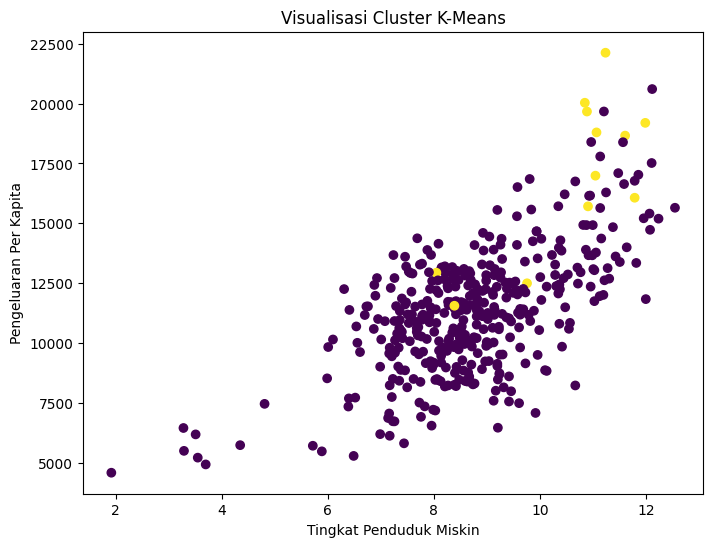

In [ ]:
#tampilkan
#visualisasi sederhana
plt.figure(figsize=(8,6))

plt.scatter(
    feature_train['Rata-rata Lama Sekolah'],
    feature_train['PengeluaranPerKapita'],
    c=feature_train['Cluster']
)

plt.xlabel('Tingkat Penduduk Miskin')
plt.ylabel('Pengeluaran Per Kapita')
plt.title('Visualisasi Cluster K-Means')

plt.show()

visualisasi dan lihat persebaran data  pada fitur test

In [ ]:
print(feature_test[['Kabupaten_Kota', 'Cluster']].head())

          Kabupaten_Kota  Cluster
304            Manggarai        0
497                Asmat        0
440            Gorontalo        0
153  Kota Tanjung Pinang        0
499              Dogiyai        0


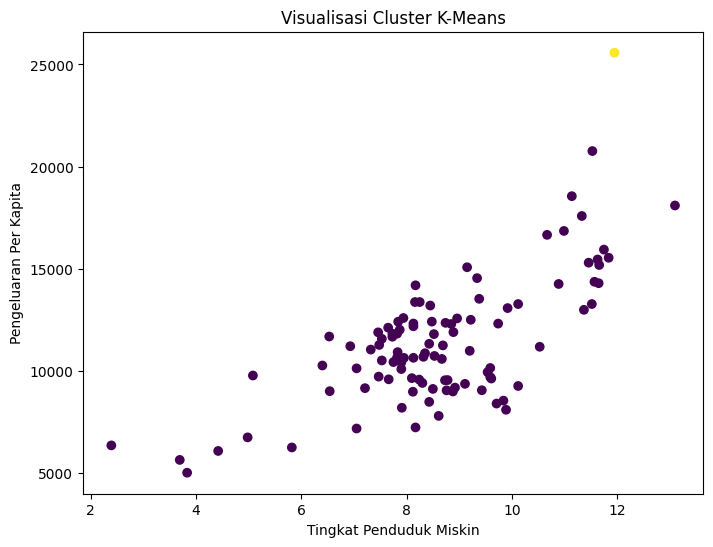

In [ ]:
#tampilkan
#visualisasi sederhana
plt.figure(figsize=(8,6))

plt.scatter(
    feature_test['Rata-rata Lama Sekolah'],
    feature_test['PengeluaranPerKapita'],
    c=feature_test['Cluster']
)

plt.xlabel('Tingkat Penduduk Miskin')
plt.ylabel('Pengeluaran Per Kapita')
plt.title('Visualisasi Cluster K-Means')

plt.show()